In [1]:
import torch
from torch.utils.data import Dataset
import numpy as np
import matplotlib.pyplot as plt
import cv2
import h5py

In [2]:
def print_structure(f, indent=0):
    for key in f.keys():
        print('  ' * indent + key, ':', type(f[key]).__name__)
        if hasattr(f[key], 'keys'):
            print_structure(f[key], indent + 1)

In [3]:
with h5py.File('waymo_open_dataset/training.h5', 'r') as f:
    print_structure(f['frames']['0'])
    frame = f['frames']['0']

    img_center = frame['images/center'][:]
    img_left = frame['images/left'][:]
    img_right = frame['images/right'][:]

    pose = frame['pose'][:]

    waypoints_2d = frame['waypoints_2d'][:]
    waypoints_3d = frame['waypoints_3d'][:]

    center_intrinsic  = frame['calibration/center/intrinsic'][:]
    center_extrinsic  = frame['calibration/center/extrinsic'][:]


print(img_center.shape)
print(waypoints_3d.shape)
print(waypoints_2d.shape)
print(pose.shape)

calibration : Group
  center : Group
    extrinsic : Dataset
    intrinsic : Dataset
  left : Group
    extrinsic : Dataset
    intrinsic : Dataset
  right : Group
    extrinsic : Dataset
    intrinsic : Dataset
images : Group
  center : Dataset
  left : Dataset
  right : Dataset
pose : Dataset
waypoints_2d : Dataset
waypoints_3d : Dataset
(1079, 972, 3)
(20, 3)
(20, 2)
(4, 4)


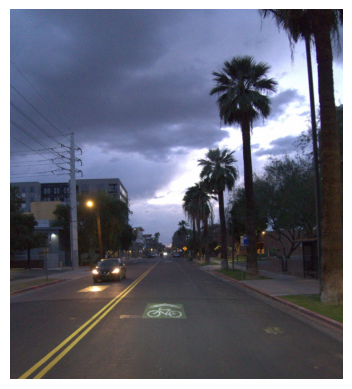

In [4]:
plt.imshow(img_center)
plt.axis('off') 
plt.show()

In [6]:
class WaymoDataset:
    def __init__(self, h5_path):
        self.path = h5_path
        with h5py.File(h5_path, 'r') as f:
            self.frame_keys = sorted(f['frames'].keys(), key=int)
    
    def __len__(self):
        return len(self.frame_keys)
    
    def __getitem__(self, idx):
        key = self.frame_keys[idx]

        with h5py.File(self.path, 'r') as f:
            frame = f['frames'][key]
            
            img_center = frame['images/center'][:]
            img_left = frame['images/left'][:]
            img_right = frame['images/right'][:]

            pose = frame['pose'][:]

            waypoints_2d = frame['waypoints_2d'][:]
            waypoints_3d = frame['waypoints_3d'][:]

            center_intrinsic  = frame['calibration/center/intrinsic'][:]
            center_extrinsic  = frame['calibration/center/extrinsic'][:]

        
        img_center = torch.tensor(img_center).permute(2, 0, 1).float() / 255.0
        img_left = torch.tensor(img_left).permute(2, 0, 1).float() / 255.0
        img_right = torch.tensor(img_right).permute(2, 0, 1).float() / 255.0

        pose = torch.tensor(pose).float()

        waypoints_2d = torch.tensor(waypoints_2d).float()
        waypoints_3d = torch.tensor(waypoints_3d).float()

        center_intrinsic = torch.tensor(center_intrinsic).float()
        center_extrinsic = torch.tensor(center_extrinsic).float()

        return {
            'img_center' : img_center,
            'img_left' : img_left,
            'img_right' : img_right,
            'pose' : pose,
            'waypoints_3d' : waypoints_3d
        }